In [7]:
import torch
import torch.nn as nn
import random, os
from PIL import Image

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import torchvision.datasets as datasets
import torch.nn.functional as F 
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)

device = cuda


In [8]:
class SynchronizedTransform:
    def __init__(self, rotation_range=15, scale_range=(1, 1.2)):
        self.rotation_range = rotation_range
        self.scale_range = scale_range

    def __call__(self, past_img, present_img):
        angle = random.uniform(0, self.rotation_range)
        scale = random.uniform(self.scale_range[0], self.scale_range[1])

        transform = transforms.Compose([
            transforms.Resize((640, 640)),
              transforms.RandomAffine(degrees=angle, scale=(scale, scale), fill=255),
            transforms.ToTensor()
              lambda x:x/255.0
        ])

        return transform(past_img), transform(present_img)

In [9]:
class SimpleImageDataset(Dataset):
    def __init__(self, past_dir, present_dir, transform=None):
        self.past_dir = past_dir
        self.present_dir = present_dir
        self.transform = transform
        
          อ่านไฟล์ทั้งหมดจากโฟลเดอร์ Past
        past_files = [f for f in os.listdir(past_dir) 
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
          อ่านไฟล์ทั้งหมดจากโฟลเดอร์ Present
        present_files = [f for f in os.listdir(present_dir) 
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
          หาไฟล์ที่มีชื่อเหมือนกันใน 2 โฟลเดอร์
        matching_files = []
        for past_file in past_files:
            if past_file in present_files:
                matching_files.append(past_file)
        
          สร้าง pairs ของไฟล์
        self.pairs = []
        for filename in matching_files:
            past_path = os.path.join(past_dir, filename)
            present_path = os.path.join(present_dir, filename)
            
              ตรวจสอบว่าไฟล์มีอยู่จริง
            if os.path.exists(past_path) and os.path.exists(present_path):
                self.pairs.append((past_path, present_path))
        
        print(f"Found {len(self.pairs)} matching image pairs")
        if len(self.pairs) == 0:
            raise ValueError("No matching image pairs found!")
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        past_path, present_path = self.pairs[idx]
        
        past_img = Image.open(past_path).convert("RGB")
        present_img = Image.open(present_path).convert("RGB")
        
        if self.transform:
            if isinstance(self.transform, SynchronizedTransform):
                past_img, present_img = self.transform(past_img, present_img)
            else:
                  ใช้ seed เดียวกันสำหรับทั้งสองภาพ
                seed = random.randint(0, 2147483647)
                random.seed(seed)
                torch.manual_seed(seed)
                past_img = self.transform(past_img)
                random.seed(seed)
                torch.manual_seed(seed)
                present_img = self.transform(present_img)
        
        return past_img, present_img

sync_transform = SynchronizedTransform(rotation_range=15, scale_range=(0.8, 1.2))
dataset = SimpleImageDataset("Past_Augmented", "Present_Augmented", transform=sync_transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False)

for past, present in dataloader:
    print(past.shape, present.shape)
    break


Found 608 matching image pairs
torch.Size([64, 3, 640, 640]) torch.Size([64, 3, 640, 640])


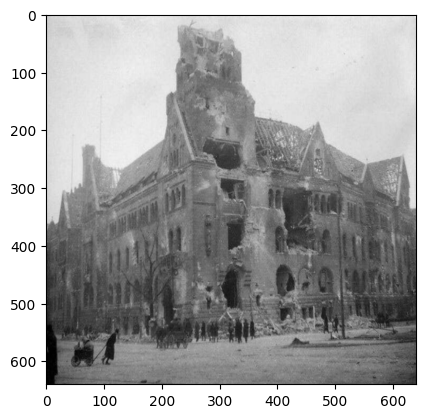

In [10]:
pastt, persentt = dataset[0]

plt.imshow(pastt.permute(1, 2, 0).cpu().numpy())
plt.show()

In [11]:
class CNN_PastImage(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1, stride=2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1, stride=2)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=128, kernel_size=3, padding=1, stride=2)
        self.conTrans1 = nn.ConvTranspose2d(in_channels=128, out_channels=32, kernel_size=3, padding=1, stride=2, output_padding=1)
        self.conTrans2 = nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3, padding=1, stride=2, output_padding=1)
        self.conTrans3 = nn.ConvTranspose2d(in_channels=16, out_channels=3, kernel_size=3, padding=1, stride=2, output_padding=1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conTrans1(x))
        x = F.relu(self.conTrans2(x))
        x = F.sigmoid(self.conTrans3(x))
        return x

model = CNN_PastImage().to(device)
  summary(model, )


In [12]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epochs = 300
model.train()

for epoch in range(epochs):
    for past_imgs, present_imgs in dataloader:
        past_imgs = past_imgs.to(device)
        present_imgs = present_imgs.to(device)
        output = model(past_imgs)
        loss = criterion(output.to(device), present_imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

      if epoch % 10 == 0:
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")

Epoch 1/300, Loss: 0.0886891558766365
Epoch 2/300, Loss: 0.0884963721036911
Epoch 3/300, Loss: 0.08823831379413605
Epoch 4/300, Loss: 0.08785004913806915
Epoch 5/300, Loss: 0.08729860186576843
Epoch 6/300, Loss: 0.0865156352519989
Epoch 7/300, Loss: 0.08561374247074127
Epoch 8/300, Loss: 0.08474403619766235
Epoch 9/300, Loss: 0.0839216411113739
Epoch 10/300, Loss: 0.0830359011888504
Epoch 11/300, Loss: 0.08212323486804962
Epoch 12/300, Loss: 0.08121520280838013
Epoch 13/300, Loss: 0.08026531338691711
Epoch 14/300, Loss: 0.07934046536684036
Epoch 15/300, Loss: 0.07837118953466415
Epoch 16/300, Loss: 0.07739453762769699
Epoch 17/300, Loss: 0.07645625621080399
Epoch 18/300, Loss: 0.07555973529815674
Epoch 19/300, Loss: 0.07473669201135635
Epoch 20/300, Loss: 0.07396507263183594
Epoch 21/300, Loss: 0.07324681431055069
Epoch 22/300, Loss: 0.07254347950220108
Epoch 23/300, Loss: 0.07188382744789124
Epoch 24/300, Loss: 0.07127358764410019
Epoch 25/300, Loss: 0.07068030536174774
Epoch 26/300, 

torch.Size([64, 3, 640, 640])


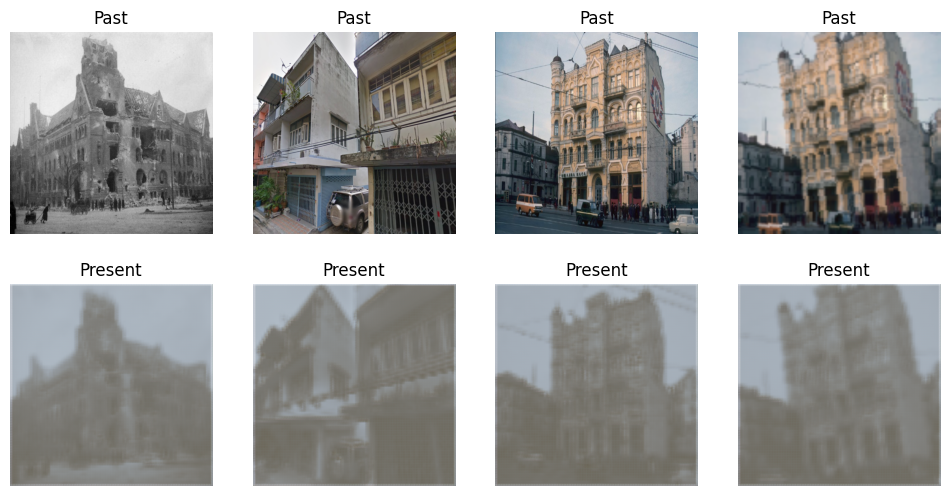

In [14]:
imags, _ = next(iter(dataloader))

model.eval()
with torch.no_grad():
    output = model(imags.to(device))
print(output.shape)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    input_image = imags[i].permute(1, 2, 0).cpu().numpy()
    output_image = output[i].permute(1, 2, 0).cpu().numpy()

    input_image = np.clip(input_image, 0, 1)
    output_image = np.clip(output_image, 0, 1)
    axes[0, i].imshow(input_image)
    axes[0, i].set_title('Past')
    axes[0, i].axis('off')

    axes[1, i].imshow(output_image)
    axes[1, i].set_title('Present')
    axes[1, i].axis('off')